In [1]:
import os
import sys
import json
project_dir = os.path.dirname(os.getcwd())
sys.path.append(project_dir)

import numpy as np  # Ensure this is imported if not already


import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = torch.Generator().manual_seed(42)
print(device)

cuda


# Data

In [2]:
from data.cifar10 import get_cifar10_pipeline

train_loader, val_loader, test_loader = get_cifar10_pipeline(batch_size=128, indexed=True)
sample_x, sample_y, idx = next(iter(train_loader))
print(sample_x.shape)
print(sample_y.shape)
print(idx.shape)

Files already downloaded and verified
Files already downloaded and verified
torch.Size([128, 3, 32, 32])
torch.Size([128])
torch.Size([128])


# Self Distill

In [ ]:
import tqdm
from utils.train import evaluate_model
from utils.losses import DistillationLoss, Accuracy


def self_distill_model(train_loader, model, criterion, optimizer, scheduler, 
                       device, teacher_logits_dict, epoch=0, warmup_epochs=10):
    model.train()
    epoch_loss = []

    for inputs, labels, indices in tqdm.tqdm(train_loader, desc='training...', file=sys.stdout):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        # Determine if we can apply self-distillation
        if epoch >= warmup_epochs and all(idx.item() in teacher_logits_dict for idx in indices):
            prev_logits = torch.stack([teacher_logits_dict[idx.item()] for idx in indices]).to(device)
            loss = criterion(outputs, prev_logits.detach(), labels)
        else:
            loss = F.cross_entropy(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Store current logits for self-distillation in next epoch
        for i, idx in enumerate(indices):
            teacher_logits_dict[idx.item()] = outputs[i].detach().clone()

        epoch_loss.append(loss.item())

    scheduler.step()
    return np.mean(epoch_loss)


def distill_val(train_loader, val_loader, model, criterion, optimizer, scheduler, 
                device='cpu', aux_metrics={}, path="./temp.pth", patience=50, epochs=50):
    metrics = {"train_loss": [], "accuracy": []}
    for k in aux_metrics.keys():
        metrics[k] = []

    teacher_logits_dict = {}
    best_val_acc = 0
    counter = 0
    for epoch in range(epochs):
        train_loss = self_distill_model(train_loader, model, criterion, optimizer, scheduler, device, teacher_logits_dict, epoch=epoch)
        val_acc = evaluate_model(val_loader, model, Accuracy(), device)
        metrics['train_loss'].append(train_loss)
        metrics['accuracy'].append(val_acc)
        for k, v in aux_metrics.items():
            metrics[k].append(evaluate_model(val_loader, model, v, device))
        if metrics['accuracy'][-1] >= best_val_acc:
            best_val_acc = metrics['accuracy'][-1]
            counter = 0
            print(f"Epoch {epoch+1}: New best accuracy: {best_val_acc:.4f} saving model...")
            state = {
                'epoch': epoch,
                'state_dict': model.state_dict(),
                'optimizer': optimizer.state_dict()
            }
            state.update({k: metrics[k][-1] for k in metrics.keys()})
            torch.save(state, path)
        else:
            counter += 1
        if counter >= patience:
            print(f"Epoch {epoch+1}: Early stop triggered.")
            break
    return metrics

In [4]:
from models.resnet import resnet34, resnet50
from utils.plots import plot_training_metrics
from utils.losses import DistillationLoss
import torch.optim as optim

collection = []
As = [0.2, 0.8]
for a in As:
    model = resnet50().to(device)
    criterion = DistillationLoss(T=3.0, alpha=a)
    optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)
    path = f'../models/weights/cifar10_resnet50_a{int(a*100)}.pth'
    metrics = distill_val(train_loader, val_loader, model, criterion, optimizer, scheduler, 
                        device=device, path=path, patience=50, epochs=50)
    collection.append(metrics)
    with open(os.path.join(project_dir, f'data/states/cifar10_resnet50_a{int(a*100)}.json'), 'w') as f:
        json.dump(metrics, f) 

evaluating...: 100%|██████████| 16/16 [00:01<00:00, 12.98it/s]
Epoch 1: New best accuracy: 0.3864 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 13.21it/s]
Epoch 2: New best accuracy: 0.4900 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 12.74it/s]
Epoch 3: New best accuracy: 0.5357 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 13.41it/s]
Epoch 4: New best accuracy: 0.5854 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 12.82it/s]
Epoch 5: New best accuracy: 0.6408 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 13.30it/s]
Epoch 6: New best accuracy: 0.6431 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 13.51it/s]
Epoch 7: New best accuracy: 0.7018 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 13.60it/s]
Epoch 9: New best accuracy: 0.7771 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 13.22it/s]
Epoch 10: New best accura

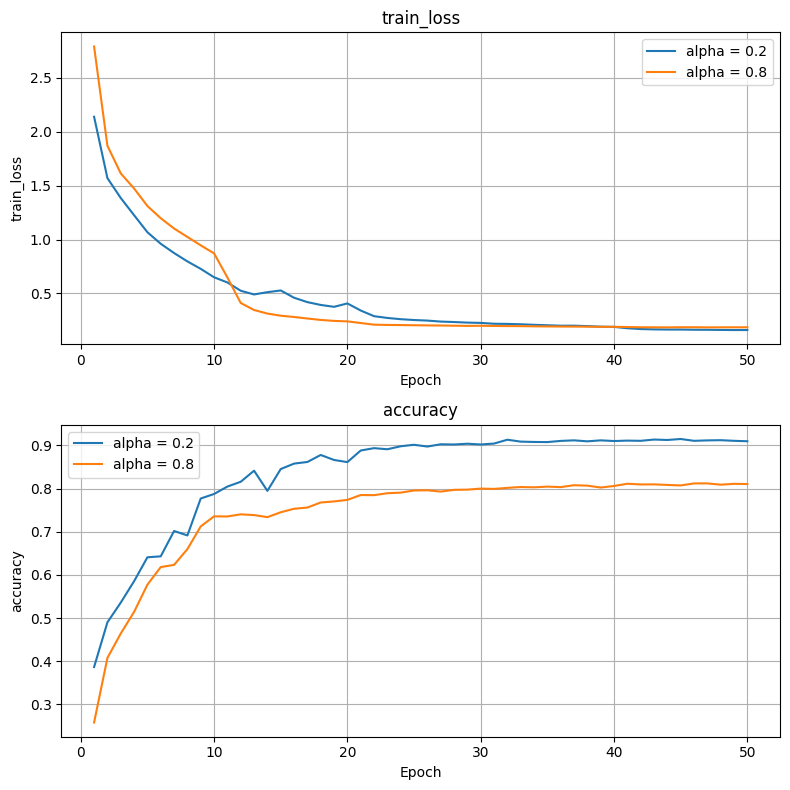

In [5]:
import matplotlib.pyplot as plt

# modified
num_metrics = len(metrics)
fig, axes = plt.subplots(num_metrics, 1, figsize=(8, 4 * num_metrics))
if num_metrics == 1:
    axes = [axes]
epochs = range(1, len(next(iter(metrics.values()))) + 1)
for i, k in enumerate(metrics.keys()):
    for j in range(len(collection)):
        axes[i].plot(epochs, collection[j][k], label=f"alpha = {As[j]}")
    axes[i].set_title(k)
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel(k)
    axes[i].legend()
    axes[i].grid(True)
plt.tight_layout()
plt.show()

# Long

evaluating...: 100%|██████████| 16/16 [00:01<00:00, 15.05it/s]
Epoch 1: New best accuracy: 0.3629 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 14.96it/s]
Epoch 2: New best accuracy: 0.4174 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 15.04it/s]
Epoch 3: New best accuracy: 0.4560 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 15.27it/s]
Epoch 4: New best accuracy: 0.5423 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 14.81it/s]
Epoch 5: New best accuracy: 0.6099 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 14.54it/s]
Epoch 6: New best accuracy: 0.6494 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 15.34it/s]
Epoch 7: New best accuracy: 0.6614 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 15.02it/s]
Epoch 8: New best accuracy: 0.7166 saving model...
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 14.93it/s]
Epoch 10: New best accura

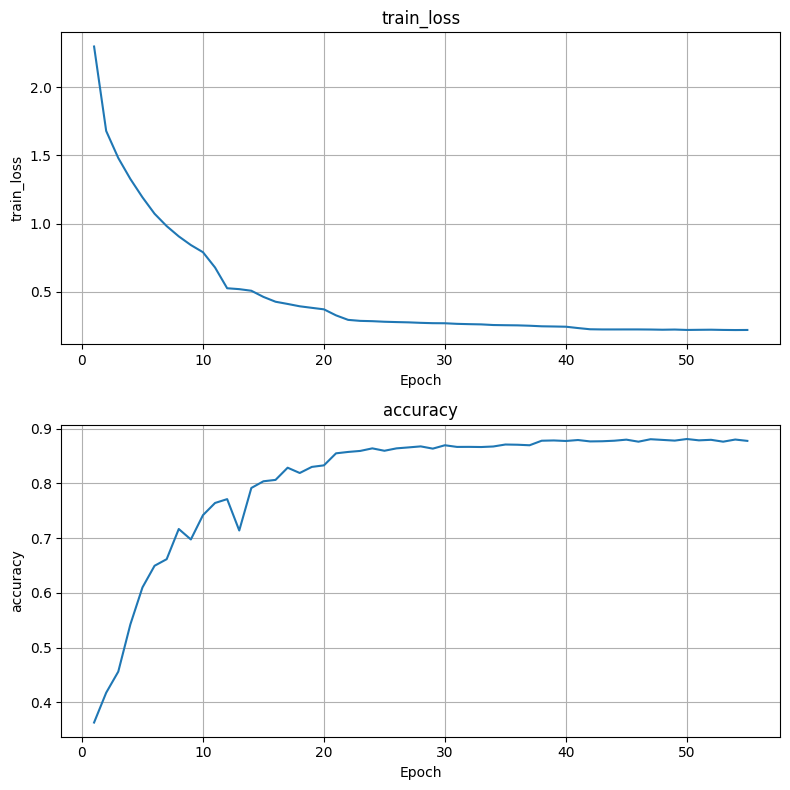

In [6]:
from models.resnet import resnet34, resnet50
from utils.plots import plot_training_metrics
from utils.losses import DistillationLoss
import torch.optim as optim

a = 0.5
model = resnet50().to(device)
criterion = DistillationLoss(T=3.0, alpha=a)
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)
path = f'../models/weights/cifar10_resnet50_a{int(a*100)}_long.pth'
metrics = distill_val(train_loader, val_loader, model, criterion, optimizer, scheduler, 
                    device=device, path=path, patience=5, epochs=100)
with open(os.path.join(project_dir, f'data/states/cifar10_resnet50_a{int(a*100)}_long.json'), 'w') as f:
    json.dump(metrics, f) 
plot_training_metrics(metrics)

# Evaluations

In [ ]:
from utils.train import evaluate_model
from utils.losses import Accuracy

student_path = '../models/final_weights/cifar10_resnet50_a20.pth'
teacher_path = '../models/final_weights/cifar10_resnet50_larger.pth'
smaller_path = '../models/final_weights/cifar10_resnet50_student.pth'

teacher_state = torch.load(teacher_path, map_location=device)
smaller_state = torch.load(smaller_path, map_location=device)
student_state = torch.load(student_path, map_location=device)
print(f"Teacher: Val Accuracy: {teacher_state['accuracy']:.4f}")
print(f"Smaller: Val Accuracy: {smaller_state['accuracy']:.4f}")
print(f"Student: Val Accuracy: {student_state['accuracy']:.4f}")

teacher = mlp.mnist1200().to(device)
smaller = mlp.mnist800().to(device)
student = mlp.mnist800().to(device)
teacher.load_state_dict(teacher_state['state_dict'])
smaller.load_state_dict(smaller_state['state_dict'])
student.load_state_dict(student_state['state_dict'])

teacher_test_acc = evaluate_model(test_loader, teacher, Accuracy(), device)
smaller_test_acc = evaluate_model(test_loader, smaller, Accuracy(), device)
student_test_acc = evaluate_model(test_loader, student, Accuracy(), device)
print(f"Teacher: Test Accuracy: {teacher_test_acc:.4f}")
print(f"Smaller: Test Accuracy: {smaller_test_acc:.4f}")
print(f"Student: Test Accuracy: {student_test_acc:.4f}")